In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2

light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

In [4]:
delta_r = 0.1
data1 = pd.read_excel("данные.xlsx", sheet_name="кольца")[['m', 'r_min, cm', 'r_max, cm']]
data1

,m,"r_min, cm","r_max, cm"
0,1,2.446386,2.913253
1,2,3.585542,3.977711
2,3,4.481928,4.780723
3,4,5.191566,5.453012
4,5,5.826506,6.087952
5,6,6.368072,6.629518
6,7,6.909639,7.096386
7,8,7.413855,7.619277
8,9,7.843373,8.011446


In [16]:
data1["r_avg^2, cm^2"] = ((data1["r_max, cm"] + delta_r)**2 + (data1["r_max, cm"] - delta_r)**2)/2
data1["r^2_sigma, cm^2"] = ((data1["r_max, cm"] + delta_r)**2 - (data1["r_max, cm"] - delta_r)**2)/2
pd.set_option('display.precision', 1)
data1

,m,"r_min, cm","r_max, cm","r_avg^2, cm^2","r^2_sigma, cm^2"
0,1,2.4,2.9,8.5,0.6
1,2,3.6,4.0,15.8,0.8
2,3,4.5,4.8,22.9,1.0
3,4,5.2,5.5,29.7,1.1
4,5,5.8,6.1,37.1,1.2
5,6,6.4,6.6,44.0,1.3
6,7,6.9,7.1,50.4,1.4
7,8,7.4,7.6,58.1,1.5
8,9,7.8,8.0,64.2,1.6


In [9]:
def linear0(x, k):
    return k*x
popt, pcov = opt.curve_fit(linear0, 
                             data1["m"], 
                             data1["r_avg^2, cm^2"], 
                             sigma = data1["r^2_sigma, cm^2"], 
                             absolute_sigma = True)
k = popt[0]
delta_k = pcov[0][0]**0.5
k, delta_k

(7.33860326957169, 0.08075559465545026)

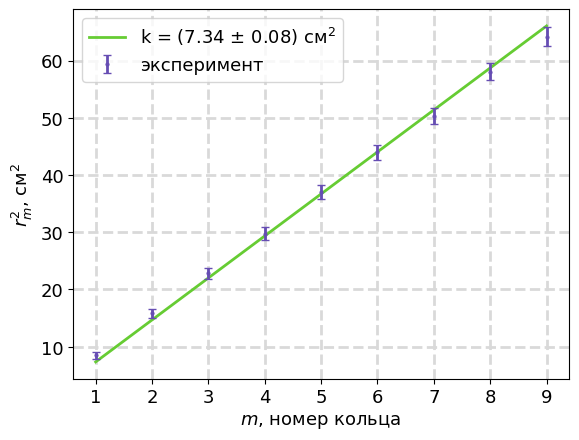

In [13]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

m_th = np.linspace(1, 9, 2)
plt.plot(m_th, k * m_th, color = light_green, label = f"k = ({k:.2f}" + r' $\pm$ ' + f"{delta_k:.2f}) " + r'$\text{см}^2$')
plt.errorbar(data1["m"], data1["r_avg^2, cm^2"], 
             yerr = data1["r^2_sigma, cm^2"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'эксперимент',
             color = dark_purple)
plt.ylabel(r'$r_m^2$, $\text{см}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.legend()
plt.savefig('pics/rings.png', dpi = 300)

In [15]:
l = 3 #cm
lambda_0 = 0.63 * 1e-4 #cm 
n_0 = 2.29
L_0 = 76 #cm
L = L_0 - l/2
delta_L = 1
dn = lambda_0 * n_0**2 * L**2/l/k
delta_dn = (2*(delta_L/L)**2 + (delta_k/k)**2)**0.5 * dn
dn, delta_dn

(0.08328933505090182, 0.0018275072435662257)

71.67914469953178